<a href="https://colab.research.google.com/github/soumilijn-tech/AIML-LAB/blob/main/LAB_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib

Problem 1: BFS and DFS Traversal of a Graph:
Problem Statement:
A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:
1. Stores the graph using an adjacency list (a Python dictionary).
2. Performs a BFS traversal starting from node A.
3. Performs a DFS traversal starting from node A.
4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes

BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


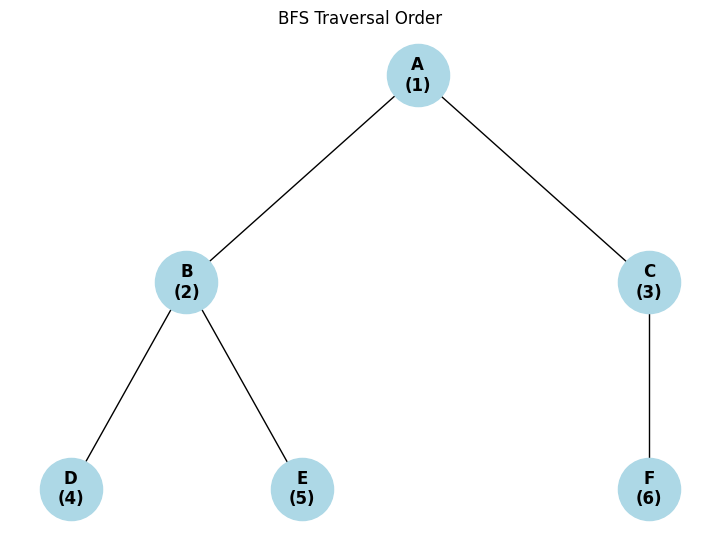

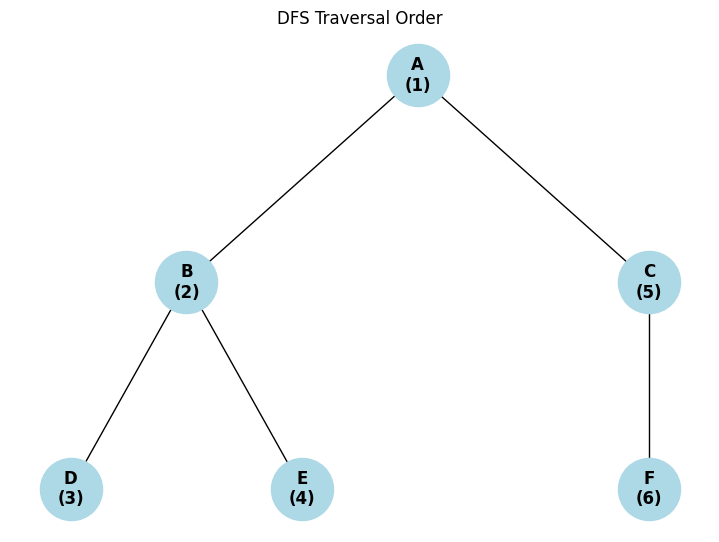

In [2]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

# 1. Graph using adjacency list
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# 2. BFS Traversal
def bfs(graph, start):
    visited = set()
    queue = deque([start])
    order = []

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.add(node)
            order.append(node)

            for neighbour in graph[node]:
                if neighbour not in visited:
                    queue.append(neighbour)

    return order


# 3. DFS Traversal
def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()

    if order is None:
        order = []

    visited.add(start)
    order.append(start)

    for neighbour in graph[start]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited, order)

    return order


# Perform traversals
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))


# Function to draw tree with traversal order
def draw_tree(graph, order, title):
    G = nx.DiGraph()

    for node in graph:
        for neighbour in graph[node]:
            G.add_edge(node, neighbour)

    pos = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    labels = {
        node: f"{node}\n({order.index(node) + 1})"
        for node in order
    }

    plt.figure(figsize=(7, 5))
    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,
        node_size=2000,
        node_color="lightblue",
        font_size=12,
        font_weight="bold",
        arrows=False
    )

    plt.title(title)
    plt.show()


# Draw BFS and DFS trees
draw_tree(graph, bfs_order, "BFS Traversal Order")
draw_tree(graph, dfs_order, "DFS Traversal Order")